In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
os.environ["PYTHONWARNINGS"] = "ignore"
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/gpreda/bbc-news/bbc_news.csv


In [2]:
import sys
import os
import warnings

# Silence Python warnings
warnings.filterwarnings("ignore")

# Silence stderr (where Jupyter prints that warning)
sys.stderr = open(os.devnull, 'w')

print("Warnings fully disabled ✅")

Warnings fully disabled ✅


In [3]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Basic libraries
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt

# NLP
import nltk
from nltk.corpus import stopwords
import spacy

# Sklearn
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import NMF

# Gensim (LDA)
import gensim
from gensim import corpora
from gensim.models import CoherenceModel

# Visualization
import pyLDAvis
import pyLDAvis.gensim_models
from wordcloud import WordCloud

print("All libraries imported successfully ✅")

All libraries imported successfully ✅


In [4]:
df = pd.read_csv("/kaggle/input/datasets/gpreda/bbc-news/bbc_news.csv")

# Combine title + description for topic modeling
df['text'] = df['title'].fillna('') + " " + df['description'].fillna('')

print("Dataset loaded successfully ✅")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully ✅
Shape: (42115, 6)


,title,pubDate,guid,link,description,text
0,Ukraine: Angry Zelensky vows to punish Russian...,"Mon, 07 Mar 2022 08:01:56 GMT",https://www.bbc.co.uk/news/world-europe-60638042,https://www.bbc.co.uk/news/world-europe-606380...,The Ukrainian president says the country will ...,Ukraine: Angry Zelensky vows to punish Russian...
1,War in Ukraine: Taking cover in a town under a...,"Sun, 06 Mar 2022 22:49:58 GMT",https://www.bbc.co.uk/news/world-europe-60641873,https://www.bbc.co.uk/news/world-europe-606418...,"Jeremy Bowen was on the frontline in Irpin, as...",War in Ukraine: Taking cover in a town under a...
2,Ukraine war 'catastrophic for global food',"Mon, 07 Mar 2022 00:14:42 GMT",https://www.bbc.co.uk/news/business-60623941,https://www.bbc.co.uk/news/business-60623941?a...,One of the world's biggest fertiliser firms sa...,Ukraine war 'catastrophic for global food' One...
3,Manchester Arena bombing: Saffie Roussos's par...,"Mon, 07 Mar 2022 00:05:40 GMT",https://www.bbc.co.uk/news/uk-60579079,https://www.bbc.co.uk/news/uk-60579079?at_medi...,The parents of the Manchester Arena bombing's ...,Manchester Arena bombing: Saffie Roussos's par...
4,Ukraine conflict: Oil price soars to highest l...,"Mon, 07 Mar 2022 08:15:53 GMT",https://www.bbc.co.uk/news/business-60642786,https://www.bbc.co.uk/news/business-60642786?a...,Consumers are feeling the impact of higher ene...,Ukraine conflict: Oil price soars to highest l...


In [5]:
# Load stopwords and spaCy model
stop_words = set(stopwords.words("english"))
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

# Function to clean text
def preprocess(text):
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r"http\S+", "", text)
    # Remove non-alphabetic characters
    text = re.sub(r"[^a-z\s]", "", text)
    # Tokenize & lemmatize using spaCy
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc if token.text not in stop_words and len(token.text) > 2]
    return " ".join(tokens)

# Apply preprocessing to combined text column
df['clean_text'] = df['text'].apply(preprocess)

# Quick check
df[['text', 'clean_text']].head()

,text,clean_text
0,Ukraine: Angry Zelensky vows to punish Russian...,ukraine angry zelensky vow punish russian atro...
1,War in Ukraine: Taking cover in a town under a...,war ukraine take cover town attack jeremy bowe...
2,Ukraine war 'catastrophic for global food' One...,ukraine war catastrophic global food one world...
3,Manchester Arena bombing: Saffie Roussos's par...,manchester arena bombing saffie roussoss paren...
4,Ukraine conflict: Oil price soars to highest l...,ukraine conflict oil price soar high level sin...


In [7]:
# --------- For LDA ---------
count_vectorizer = CountVectorizer(max_df=0.95, min_df=2)
X_counts = count_vectorizer.fit_transform(df['clean_text'])

print("LDA Count Vectorizer shape:", X_counts.shape)

# --------- For NMF ---------
tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=2)
X_tfidf = tfidf_vectorizer.fit_transform(df['clean_text'])

print("NMF TF-IDF Vectorizer shape:", X_tfidf.shape)

LDA Count Vectorizer shape: (42115, 18822)
NMF TF-IDF Vectorizer shape: (42115, 18822)


In [8]:
# Prepare data for Gensim LDA
texts = [text.split() for text in df['clean_text']]
dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

# Train LDA model
num_topics = 5  # you can change this
lda_model = gensim.models.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    passes=10,
    random_state=42
)

# Display topics
for idx, topic in lda_model.print_topics(num_words=10):
    print(f"Topic {idx}: {topic}")

Topic 0: 0.023*"england" + 0.022*"win" + 0.021*"world" + 0.013*"cup" + 0.011*"final" + 0.009*"first" + 0.009*"watch" + 0.008*"paris" + 0.008*"euro" + 0.008*"beat"
Topic 1: 0.017*"say" + 0.011*"election" + 0.008*"trump" + 0.007*"israel" + 0.007*"government" + 0.007*"party" + 0.007*"minister" + 0.006*"war" + 0.006*"gaza" + 0.006*"labour"
Topic 2: 0.014*"league" + 0.013*"city" + 0.013*"manchester" + 0.009*"man" + 0.009*"premier" + 0.009*"say" + 0.008*"liverpool" + 0.008*"starmer" + 0.008*"united" + 0.007*"club"
Topic 3: 0.014*"say" + 0.011*"police" + 0.011*"man" + 0.010*"find" + 0.009*"people" + 0.008*"die" + 0.007*"woman" + 0.007*"death" + 0.007*"year" + 0.007*"rise"
Topic 4: 0.021*"say" + 0.007*"new" + 0.007*"year" + 0.007*"bbc" + 0.006*"star" + 0.005*"first" + 0.005*"make" + 0.005*"show" + 0.004*"former" + 0.004*"film"


In [9]:
# Train NMF model
num_topics = 5  # same as LDA
nmf_model = NMF(n_components=num_topics, random_state=42)
nmf_model.fit(X_tfidf)

# Display top words per topic
feature_names = tfidf_vectorizer.get_feature_names_out()

def display_nmf_topics(model, feature_names, num_top_words):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-num_top_words - 1:-1]]
        print(f"Topic {topic_idx}: {' '.join(top_words)}\n")

display_nmf_topics(nmf_model, feature_names, 10)

Topic 0: say police people election new man bbc die woman year

Topic 1: cup world england win final league beat womens first watch

Topic 2: ukraine war russia russian ukrainian putin invasion attack russias kyiv

Topic 3: rise rate price cost energy high bill inflation interest live

Topic 4: strike day week seven past pay selection picture image take



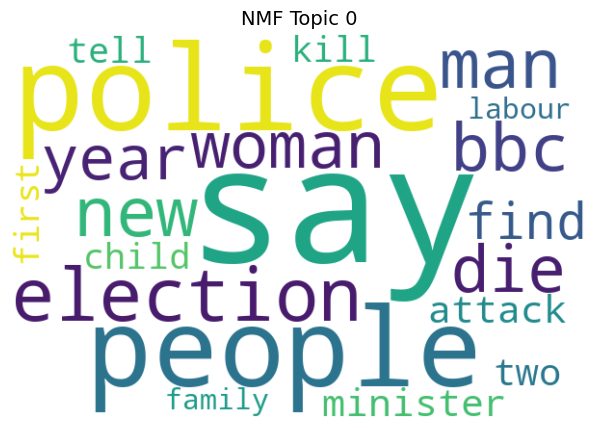

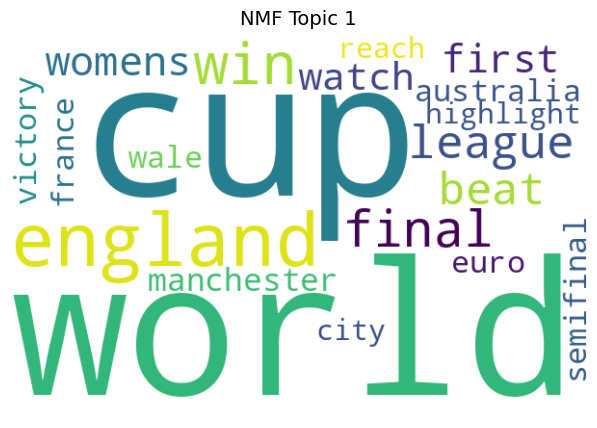

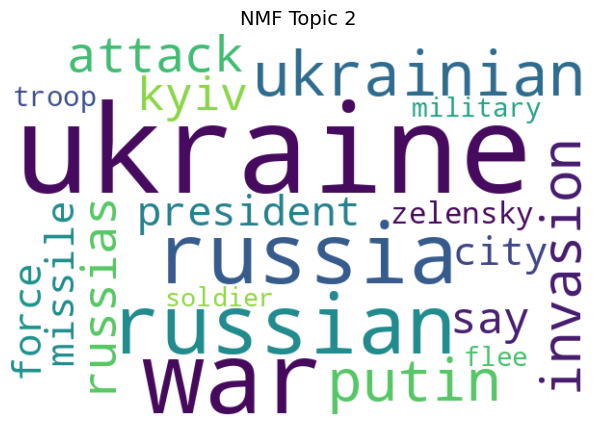

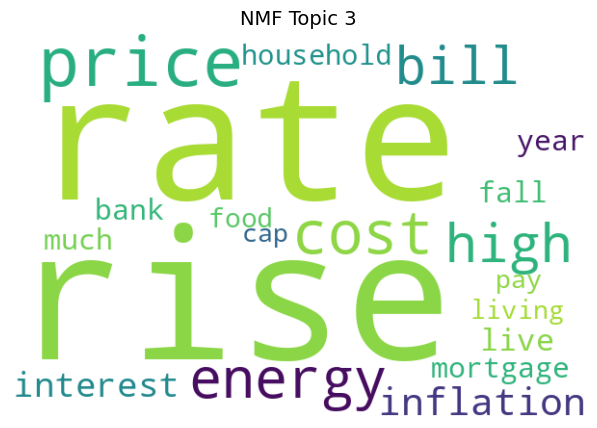

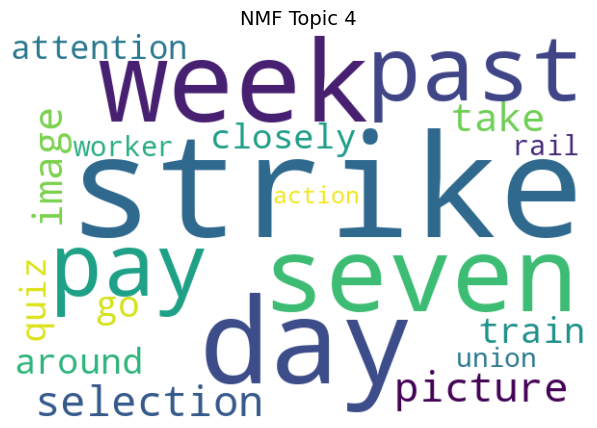

In [10]:
num_top_words = 20

for topic_idx, topic in enumerate(nmf_model.components_):
    word_freq = {feature_names[i]: topic[i] for i in topic.argsort()[-num_top_words:]}
    wc = WordCloud(width=600, height=400, background_color='white').generate_from_frequencies(word_freq)
    
    plt.figure(figsize=(8,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"NMF Topic {topic_idx}", fontsize=14)
    plt.show()

In [11]:
# Prepare visualization
lda_vis = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary)
pyLDAvis.display(lda_vis)

In [12]:
# --- LDA Coherence Score ---
coherence_lda = CoherenceModel(
    model=lda_model,
    texts=texts,
    dictionary=dictionary,
    coherence='c_v'
).get_coherence()

print(f"LDA Coherence Score: {coherence_lda:.4f}")

# --- NMF Coherence Score ---
# Convert NMF topics to Gensim-style list of words
nmf_topics = []
for topic_idx, topic in enumerate(nmf_model.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-10-1:-1]]
    nmf_topics.append(top_words)

coherence_nmf = CoherenceModel(
    topics=nmf_topics,
    texts=texts,
    dictionary=dictionary,
    coherence='c_v'
).get_coherence()

print(f"NMF Coherence Score: {coherence_nmf:.4f}")

LDA Coherence Score: 0.4081
NMF Coherence Score: 0.7167
